# Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

## Failures

In [15]:
df = pd.read_csv("../data/final/xgb_model_data.csv")

In [16]:
df['FRONTAL_IMPACT'].unique()

array([1, 0])

In [17]:
# categorize airbag deployment by predicted value and actual

# define deployment as high probability and vice versa
deployment_threshold = 0.60
no_deployment_threshold = 0.40

def categorize_case(row):
    prob = row['predicted_probability']
    actual = row['actual']
    
    if prob >= deployment_threshold and actual == 0:
        return 'expected_but_failed'
    elif prob >= deployment_threshold and actual == 1:
        return 'expected_and_deployed'
    elif prob < no_deployment_threshold and actual == 1:
        return 'unexpected_deployment'
    elif prob < no_deployment_threshold and actual == 0:
        return 'expected_no_deployment'
    else:
        return 'uncertain'
    
df['type'] = df.apply(categorize_case, axis = 1)

## False Positives

In [18]:
failures = df[df['type'] == 'expected_but_failed'].copy()

print(f"Total test cases: {len(df)}")
print(f"Expected number of deployments: {len(df[df['predicted_probability'] >= deployment_threshold])}")
print(f"Failures (false positives): {len(failures)}")
print(f"\nOverall failure rate: {len(failures) / len(df[df['predicted_probability'] >= deployment_threshold]) * 100:.2f}%")

Total test cases: 7294
Expected number of deployments: 1564
Failures (false positives): 605

Overall failure rate: 38.68%


## Feature Failure Analysis

In [19]:
expected_deployment = df[df['predicted_probability'] >= deployment_threshold]

In [20]:
def analyze_failures_by_feature(df, feature_name):
    # count failures by feature when it was expected to deploy
    failure_counts = df.groupby(feature_name).agg({
        'type': lambda x: (x == 'expected_but_failed').sum(),
        'predicted_probability': 'count'
    }).rename(columns={
        'type': 'failures',
        'predicted_probability': 'total_expected'
    })
    
    failure_counts['failure_rate'] = (
        np.round(failure_counts['failures'] / failure_counts['total_expected'] * 100, decimals = 2)
    )
    
    # filter out small sample sizes
    failure_counts = failure_counts[failure_counts['total_expected'] >= 5]

    # sort by failure rate
    failure_counts = failure_counts.sort_values('failure_rate', ascending=False)
    
    print(failure_counts.head())
    
    return failure_counts

In [21]:
# determine which makes have the highest false positives
make_analysis = analyze_failures_by_feature(expected_deployment, 'MAKENAME')

               failures  total_expected  failure_rate
MAKENAME                                             
Buick / Opel         15              29         51.72
BMW                  13              27         48.15
Mercedes-Benz        13              28         46.43
Volkswagen           15              34         44.12
GMC                  11              25         44.00


In [22]:
# determine if age of vehicle impacts false positives
year_analysis = analyze_failures_by_feature(expected_deployment, 'VEHICLE_AGE')

             failures  total_expected  failure_rate
VEHICLE_AGE                                        
23                  5               7         71.43
18                 19              28         67.86
24                  9              14         64.29
17                 27              51         52.94
26                  3               6         50.00


In [23]:
impact_analysis = analyze_failures_by_feature(expected_deployment, 'IMPACT1NAME')

                  failures  total_expected  failure_rate
IMPACT1NAME                                             
Undercarriage            5               6         83.33
Right-Front Side         9              14         64.29
5 Clock Point           10              16         62.50
6 Clock Point           18              29         62.07
Left-Back Side           6              11         54.55


In [24]:
expected_deployment

,CASENUM,VEH_NO,MAKE,MAKENAME,MOD_YEAR,MODEL,BODY_TYP,BODY_TYPNAME,VPICBODYCLASS,VPICBODYCLASSNAME,...,NUM_INJ,VEHICLE_AGE,FRONTAL_IMPACT,HIGH_SPEED_CRASH,MIN_AIRBAG_SPEED,CRASH_SEVERITY_INDEX,predicted_target,predicted_probability,actual,type
6,202305274349,2,12,Ford,1997,481,34,Light Pickup,60,Pickup,...,3,26,1,1,1,22.777778,1,0.650536,0,expected_but_failed
8,202305039328,2,42,Mercedes-Benz,2017,42,4,"4-door sedan, hardtop",13,Sedan/Saloon,...,0,6,1,1,1,15.000000,1,0.606671,1,expected_and_deployed
9,202305661844,2,49,Toyota,2006,32,4,"4-door sedan, hardtop",13,Sedan/Saloon,...,1,17,1,0,1,21.111111,1,0.772061,0,expected_but_failed
15,202304772277,2,20,Chevrolet,2018,404,14,"Compact Utility (Utility Vehicle Categories ""S...",7,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,...,1,5,1,0,0,12.222222,1,0.869975,1,expected_and_deployed
18,202304684888,2,37,Honda,2019,402,14,"Compact Utility (Utility Vehicle Categories ""S...",7,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,...,1,4,1,1,1,13.333333,1,0.781380,1,expected_and_deployed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7282,202305156232,1,35,Nissan/Datsun,2013,43,4,"4-door sedan, hardtop",13,Sedan/Saloon,...,1,10,0,1,1,31.111111,1,0.953676,1,expected_and_deployed
7286,202305289289,1,49,Toyota,2019,402,14,"Compact Utility (Utility Vehicle Categories ""S...",7,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,...,1,4,1,0,1,26.666667,1,0.915282,1,expected_and_deployed
7287,202305351110,1,49,Toyota,2023,40,4,"4-door sedan, hardtop",13,Sedan/Saloon,...,0,0,1,1,1,13.333333,1,0.830383,0,expected_but_failed
7289,202304678421,1,20,Chevrolet,2010,481,34,Light Pickup,60,Pickup,...,2,13,1,1,1,38.333333,1,0.977039,1,expected_and_deployed


In [25]:
# transform severity (continuous) to discrete bins
expected_deployment['severity_type'] = pd.cut(
    expected_deployment['CRASH_SEVERITY_INDEX'],
    bins=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

severity_analysis = analyze_failures_by_feature(expected_deployment, 'severity_type')

               failures  total_expected  failure_rate
severity_type                                        
Very Low            187             319         58.62
Very High             2               5         40.00
Low                 329             884         37.22
Medium               83             318         26.10
High                  4              38         10.53


In [26]:
# combine make and year
expected_deployment['make_year'] = (expected_deployment['MAKENAME'] + ' ' + expected_deployment['MOD_YEAR'].astype(str))

high_risk = expected_deployment.groupby('make_year').agg({
    'type': lambda x: (x == 'expected_but_failed').sum(),
    'predicted_probability': 'count'
}).rename(columns={
    'type': 'failures',
    'predicted_probability': 'total'
})

high_risk['failure_rate'] = np.round(high_risk['failures'] / high_risk['total'] * 100, decimals = 1)

high_risk_significant = high_risk[high_risk['total'] >= 5].sort_values('failure_rate', ascending=False)

# display top 10 failure rates by make/model
high_risk_significant.head(10)

,failures,total,failure_rate
make_year,,,
Ford 2001,4,5,80.0
Ford 2010,4,5,80.0
Toyota 2017,5,7,71.4
Chevrolet 2005,5,7,71.4
Toyota 2012,7,10,70.0
Honda 2009,9,13,69.2
Honda 2007,4,6,66.7
Dodge 2017,4,6,66.7
Honda 2014,4,6,66.7


In [27]:
# to save plots 
folder_name = "../reports/"

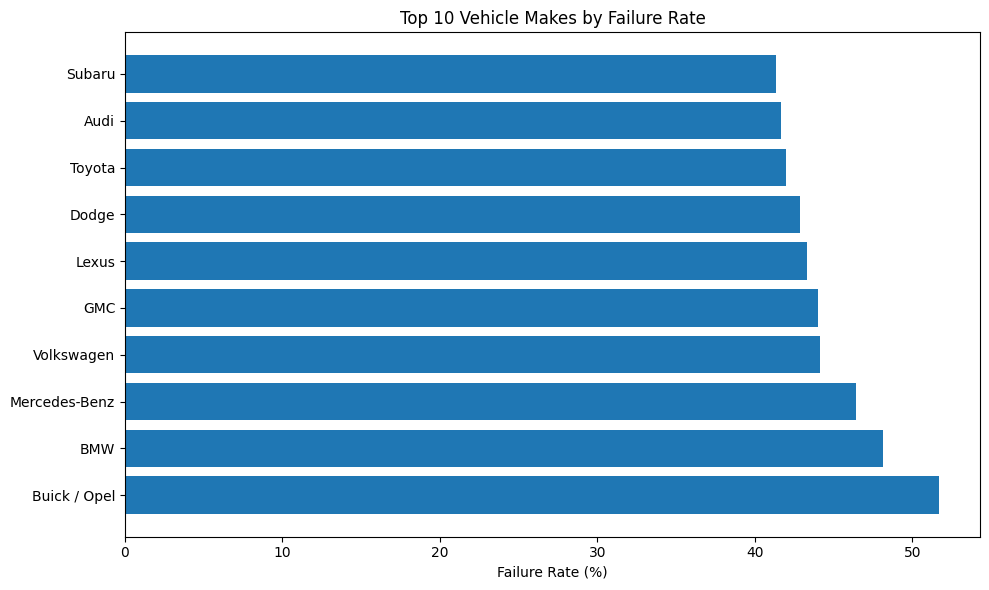

In [28]:
plt.figure(figsize=(10, 6))
make_plot_data = make_analysis.head(10)
plt.barh(make_plot_data.index, make_plot_data['failure_rate'])
plt.xlabel('Failure Rate (%)')
plt.title('Top 10 Vehicle Makes by Failure Rate')
plt.tight_layout()

# save plot
file_name = "highest_failure_rates.png"
file_path = os.path.join(folder_name, file_name)

plt.savefig(file_path)
plt.show()

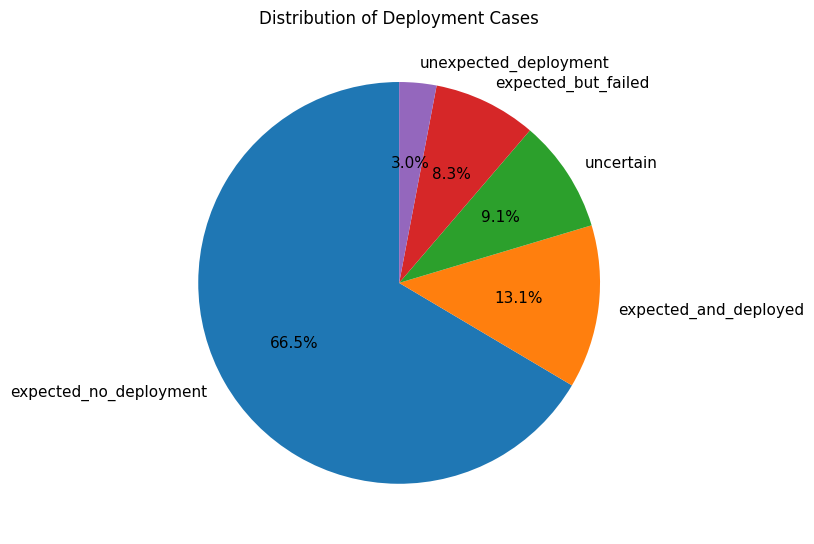

In [29]:
plt.figure(figsize=(8, 8))
case_counts = df['type'].value_counts()
plt.pie(case_counts.values, labels=case_counts.index, autopct='%1.1f%%', startangle=90,  textprops={'fontsize': 11})
plt.title('Distribution of Deployment Cases')
plt.tight_layout()

# save plot
file_name = "deployment_types_pie_chart.png"
file_path = os.path.join(folder_name, file_name)

plt.savefig(file_path)
plt.show()